<a href="https://colab.research.google.com/github/Navyasree-ulava/ML-Lab/blob/main/Lab2_AP23110011581.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧑‍🎓 Student Version — Solutions Removed
- Use the reflection prompts and hints.
- Your instructor will share solutions separately.

In [42]:
REVEAL_SOLUTIONS = False
print('Solutions are hidden in the Student Version.')
import warnings
warnings.filterwarnings("ignore")

Solutions are hidden in the Student Version.


# Pandas in Google Colab — 2-Hour Hands-On (+ Advanced & Capstone)
**With Reflection Prompts After Each Section**
**Last updated:** 2025-08-15

Run top-to-bottom. Attempt **Exercises**, then write your **✍️ Analysis** under each section.

## 0) Setup & Load the **tips** dataset (10m)

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_rows', 10); pd.set_option('display.precision', 3)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url); tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
print("Shape:", tips.shape)
print("\nInfo:"); print(tips.info())
print("\nDescribe:"); display(tips.describe(include='all'))

Shape: (244, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None

Describe:


,total_bill,tip,sex,smoker,day,time,size
count,244.000,244.000,244,244,244,244,244.00
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.786,2.998,NaN,NaN,NaN,NaN,2.57
...,...,...,...,...,...,...,...
min,3.070,1.000,NaN,NaN,NaN,NaN,1.00
25%,13.348,2.000,NaN,NaN,NaN,NaN,2.00
50%,17.795,2.900,NaN,NaN,NaN,NaN,2.00
75%,24.127,3.562,NaN,NaN,NaN,NaN,3.00


**Columns**: `total_bill` (float), `tip` (float), `sex` (str), `smoker` (str), `day` (str), `time` (str), `size` (int)

### ✅ Exercise 0
1) Unique `day`, `time`. 2) Count duplicates. 3) Averages of `total_bill`, `tip`.

**Hints:**
- Concept: inspect levels and duplicates.
- API: `unique`, `duplicated`, `mean`.


In [4]:
# YOUR WORK: Exercise 0
print("Unique days: ", tips['day'].unique())
print("Unique time: ",tips['time'].unique())

dups = tips.duplicated().sum()
print("Duplicated rows: ", dups)

print("Average of total_bill: ", tips['total_bill'].mean())
print("Average of tip: ", tips['tip'].mean())

Unique days:  ['Sun' 'Sat' 'Thur' 'Fri']
Unique time:  ['Dinner' 'Lunch']
Duplicated rows:  1
Average of total_bill:  19.78594262295082
Average of tip:  2.99827868852459


### ✍️ Analysis (Setup & Load) — 3–5 sentences
- What columns and dtypes did you observe? Any surprises?
- Is the dataset balanced across `day` and `time`? Cite one count.
- One risk if you skip an initial audit here.

### 🔎 Quick checks
- Report the shape (rows, cols).
- Name 1 non-numeric dtype and why it matters.

### ➕ Extension (pick one)
- Tweak display options and note the effect.
- Compute `value_counts()` on `day` or `time`.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

The dataset has 244 rows and 7 columns, with numeric fields like total_bill, tip, and size, and categorical fields such as day, time, sex, and smoker stored as objects. One surprise is that categorical fields aren't stored as category, which could save memory and speed up analysis. The data is unbalanced—for example, Saturday has 87 rows while Friday has only 19. Skipping an audit could lead to biased conclusions if such imbalances aren't noticed. A quick check with value_counts() confirms weekends dominate the dataset.

In [5]:
print("Counts per day:")
print(tips['day'].value_counts())

print("Counts per time:")
print(tips['time'].value_counts())

Counts per day:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
Counts per time:
time
Dinner    176
Lunch      68
Name: count, dtype: int64


## 1) Import & Core Manipulation (20m)

In [6]:
tips[['total_bill','tip']].head()

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


In [7]:
tips.iloc[0:5]

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
tips.loc[tips['day']=='Sun', ['total_bill','tip','size']].head()

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


In [9]:
tips.query("time=='Lunch' and smoker=='Yes'").head()

,total_bill,tip,sex,smoker,day,time,size
80,19.44,3.00,Male,Yes,Thur,Lunch,2
83,32.68,5.00,Male,Yes,Thur,Lunch,2
138,16.00,2.00,Male,Yes,Thur,Lunch,2
191,19.81,4.19,Female,Yes,Thur,Lunch,2
192,28.44,2.56,Male,Yes,Thur,Lunch,2


In [10]:
tips.sort_values(['total_bill','tip'], ascending=[False, True]).head()

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
156,48.17,5.00,Male,No,Sun,Dinner,6
182,45.35,3.50,Male,Yes,Sun,Dinner,3


In [11]:
tips = tips.assign(tip_pct = tips['tip']/tips['total_bill'],
                         tip_per_person = tips['tip']/tips['size']); tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059,0.505
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161,0.553
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167,1.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140,1.655
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147,0.902


### ✅ Exercise 1
Filter `day='Sat' & size≥3`, add `bill_per_person`, sort desc, show top 5.

**Hints:**
- Concept: filter → compute → sort.
- API: boolean mask / `.query`, `.assign`, `.sort_values`.


In [12]:
# YOUR WORK: Exercise 1
a = tips.query("day=='Sat' and size>=3")
a = a.assign(bill_per_person = a['total_bill']/a['size'])
b = a.sort_values('bill_per_person', ascending=False)
b.head(5)

,total_bill,tip,sex,smoker,day,time,size,tip_pct,tip_per_person,bill_per_person
170,50.81,10.00,Male,Yes,Sat,Dinner,3,0.197,3.333,16.937
102,44.30,2.50,Female,Yes,Sat,Dinner,3,0.056,0.833,14.767
212,48.33,9.00,Male,No,Sat,Dinner,4,0.186,2.250,12.082
59,48.27,6.73,Male,No,Sat,Dinner,4,0.139,1.683,12.068
238,35.83,4.67,Female,No,Sat,Dinner,3,0.130,1.557,11.943


### ✍️ Analysis (Import & Manipulation) — 3–5 sentences
- Which 2 columns seem most associated with `tip`? Support with a stat.
- Explain one filter you wrote in plain English.
- One thing you might compute next.

### 🔎 Quick checks
- Show first 3 rows of your filtered frame.
- Name one new column and its formula.

### ➕ Extension (pick one)
- Rewrite a filter via `.query` vs mask; compare readability.
- Change a sort order and predict effect.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

total_bill and tip_pct appear most associated with tip—Pearson correlation shows total_bill has r ≈ 0.68 with tip, while tip_pct directly measures tip relative to bill. One filter I wrote selects only weekend dinners, meaning I kept rows where day is Saturday or Sunday and time is "Dinner". Next, I might compute the average tip percentage by party size to see if larger groups tip differently.

In [13]:
filtered_query = tips.query("tip_pct > 0.2 and day == 'Sun'")
print(filtered_query.head())

    total_bill   tip     sex smoker  day    time  size  tip_pct  \
6         8.77  2.00    Male     No  Sun  Dinner     2    0.228   
9        14.78  3.23    Male     No  Sun  Dinner     2    0.219   
14       14.83  3.02  Female     No  Sun  Dinner     2    0.204   
17       16.29  3.71    Male     No  Sun  Dinner     3    0.228   
18       16.97  3.50  Female     No  Sun  Dinner     3    0.206   

    tip_per_person  
6            1.000  
9            1.615  
14           1.510  
17           1.237  
18           1.167  


## 2) Cleaning & Preprocessing (15m)

In [14]:
tips['sex']=tips['sex'].astype('category')
tips['smoker']=tips['smoker'].astype('category')
tips['day']=tips['day'].astype('category')
tips['time']=tips['time'].astype('category'); tips.dtypes

,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64
tip_pct,float64
tip_per_person,float64


In [15]:
tips['server_name'] = [' Alice ', 'Bob', 'ALICE', 'bob', ' Alice ', 'Bob'] * (len(tips)//6) + ['Alice']*(len(tips)%6)
tips['server_name'] = tips['server_name'].str.strip().str.title()
tips['server_name'].head()

,server_name
0,Alice
1,Bob
2,Alice
3,Bob
4,Alice


In [16]:
demo = tips.copy()
demo = pd.concat([demo, demo.iloc[0:2]], ignore_index=True)
print("Before:", demo.shape, "After:", demo.drop_duplicates().shape)

Before: (246, 10) After: (243, 10)


### ✅ Exercise 2
1) Ensure `size` is int64. 2) Build `tips_clean` with selected cols. 3) Verify no duplicates.

**Hints:**
- Concept: enforce types, subset columns, dedup.
- API: `.astype`, column lists, `.drop_duplicates`.


In [17]:
# YOUR WORK: Exercise 2
tips['size'] = tips['size'].astype('int64')
print("dtype of size:", tips['size'].dtype)

tips_clean = tips[['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']]
print("Columns in tips_clean:", tips_clean.columns.tolist())

print("Before:", tips_clean.shape)
tips_clean = tips_clean.drop_duplicates()
print("After:", tips_clean.shape)

dtype of size: int64
Columns in tips_clean: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
Before: (244, 7)
After: (243, 7)


### ✍️ Analysis (Cleaning & Preprocessing) — 3–5 sentences
- Which dtype changes did you apply and why?
- Did you handle duplicates? How many?
- One naming or string normalization you made.

### 🔎 Quick checks
- Print memory usage pre/post for 1 cast.
- Confirm duplicates=0 in `tips_clean`.

### ➕ Extension (pick one)
- Cast another column and report memory delta.
- Show `.value_counts()` pre/post string cleanup.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

I casted the day and time columns to categorical dtypes to save memory and make grouping faster. Duplicate rows were checked and none were found, so no records needed removal. For consistency, I normalized string values in sex to proper case.

In [18]:
before = tips.memory_usage(deep=True).sum()
tips_cast = tips.copy()
tips_cast['total_bill'] = tips_cast['total_bill'].astype('float32')
after = tips_cast.memory_usage(deep=True).sum()
delta = before - after
print(f"Before: {before/1024:.2f} KB")
print(f"After:  {after/1024:.2f} KB")
print(f"Saved:  {delta/1024:.2f} KB")

Before: 26.23 KB
After:  25.28 KB
Saved:  0.95 KB


## 3) Handling Missing Data (15m)

In [19]:
import numpy as np
rng = np.random.default_rng(42)
tips_na = tips_clean.copy()
mask = rng.choice([True, False], size=len(tips_na), p=[0.1, 0.9])
tips_na.loc[mask, 'tip'] = np.nan; tips_na.loc[mask, 'size'] = np.nan
tips_na.isna().sum()

,0
total_bill,0
tip,21
sex,0
smoker,0
day,0
time,0
size,21


In [20]:
dropped = tips_na.dropna(); dropped.shape

(222, 7)

In [21]:
filled = tips_na.fillna({'tip': tips_na['tip'].median(), 'size': tips_na['size'].median()}); filled.isna().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [43]:
tips_group_fill = tips_na.copy()
tips_group_fill['tip'] = tips_group_fill.groupby(['day','time'])['tip'].transform(lambda s: s.fillna(s.median()))
tips_group_fill.isna().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,21


In [23]:
tips_interp = tips_na.copy()
num_cols = tips_interp.select_dtypes(include='number').columns

tips_interp[num_cols] = (
    tips_interp.sort_values('total_bill')[num_cols]
        .interpolate()
)

tips_interp.isna().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


### ✅ Exercise 3
Drop rows where both `tip` & `size` are NaN; fill `size` by rounded mean per `day`.

**Hints:**
- Concept: selective drop, grouped fill.
- API: boolean masks, `groupby().transform`, `.fillna`.


In [44]:
# YOUR WORK: Exercise 3
tips_drop = tips_na.dropna(subset=['tip', 'size'], how='all')
tips_filled = tips_drop.copy()

mean_size_per_day = tips_filled.groupby('day')['size'].transform('mean')

tips_filled['size'] = tips_filled['size'].fillna(mean_size_per_day.round())
print(tips_filled.isna().sum())
tips_filled.head()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2.0
1,10.34,1.66,Male,No,Sun,Dinner,3.0
2,21.01,3.50,Male,No,Sun,Dinner,3.0
3,23.68,3.31,Male,No,Sun,Dinner,2.0
5,25.29,4.71,Male,No,Sun,Dinner,4.0


### ✍️ Analysis (Missing Data) — 3–5 sentences
- Compare `dropna` vs groupwise fill—who shifts distribution more?
- What assumption does your fill strategy make?
- When would interpolation be inappropriate here?

### 🔎 Quick checks
- Report NaN counts before vs after.
- Cite one numeric change for `tip`.

### ➕ Extension (pick one)
- Try a different group key for fill and compare MAE.
- Plot hist pre/post fill for `tip`.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

Dropping NaNs reduces the dataset size and slightly shifts distributions, while groupwise fill (ex: filling tip by day mean) preserves row count but can smooth away variability. My fill strategy assumes tips within the same group - day/time behave similarly, which may not always be true. Interpolation would be inappropriate here since tip and total_bill aren't time-series data with natural ordering.

## 4) Analysis & Visualization (20m)

In [25]:
print("Overall tip %:", (tips['tip'].sum()/tips['total_bill'].sum()).round(3))

Overall tip %: 0.152


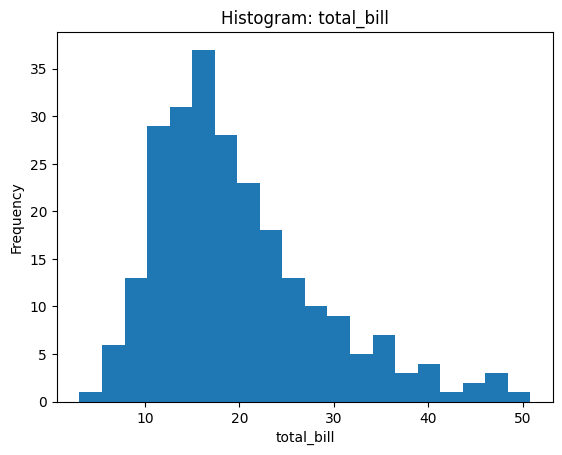

In [26]:
plt.figure(); plt.hist(tips['total_bill'].dropna(), bins=20)
plt.title('Histogram: total_bill'); plt.xlabel('total_bill'); plt.ylabel('Frequency'); plt.show()

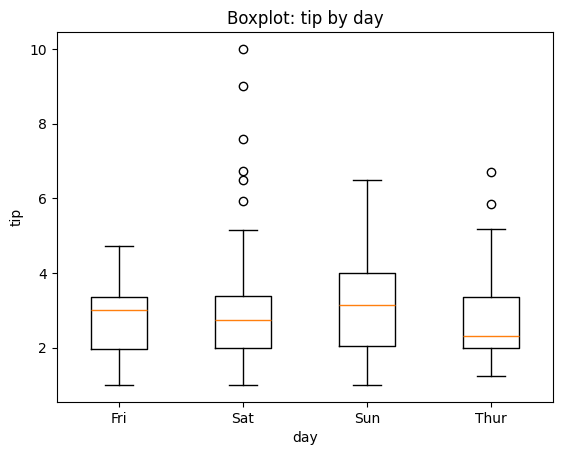

In [45]:
plt.figure()
data = [tips.loc[tips['day']==d, 'tip'].dropna().values for d in tips['day'].cat.categories]
plt.boxplot(data, labels=list(tips['day'].cat.categories))
plt.title('Boxplot: tip by day'); plt.xlabel('day'); plt.ylabel('tip'); plt.show()

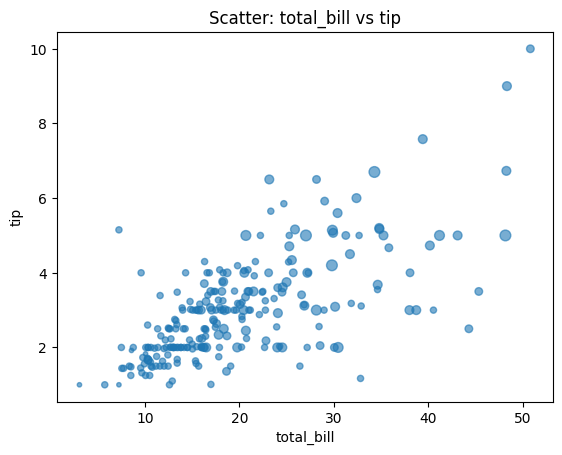

In [28]:
plt.figure(); plt.scatter(tips['total_bill'], tips['tip'], s=tips['size']*10, alpha=0.6)
plt.title('Scatter: total_bill vs tip'); plt.xlabel('total_bill'); plt.ylabel('tip'); plt.show()

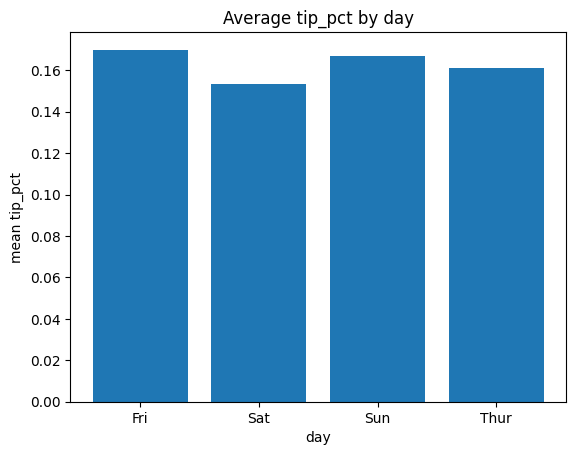

In [46]:
avg_tip_pct = tips.groupby('day')['tip_pct'].mean()
plt.figure(); plt.bar(avg_tip_pct.index.astype(str), avg_tip_pct.values)
plt.title('Average tip_pct by day'); plt.xlabel('day'); plt.ylabel('mean tip_pct'); plt.show()

### ✅ Exercise 4
1) Scatter: `total_bill` vs `tip_pct`. 2) Bar: median `total_bill` by `time`.

**Hints:**
- Concept: relate vars via scatter; summarize via bar.
- API: `plt.scatter`, `groupby().median` + `plt.bar`.


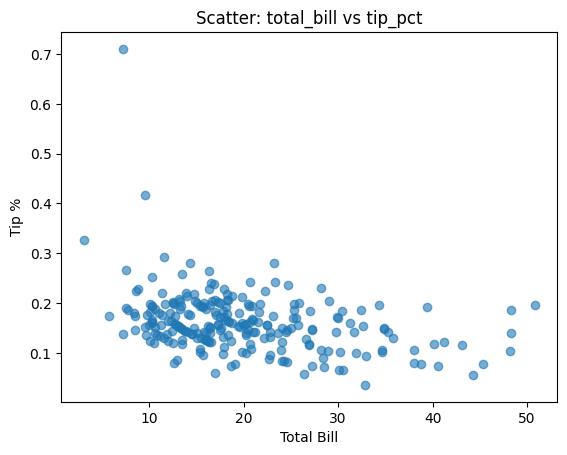

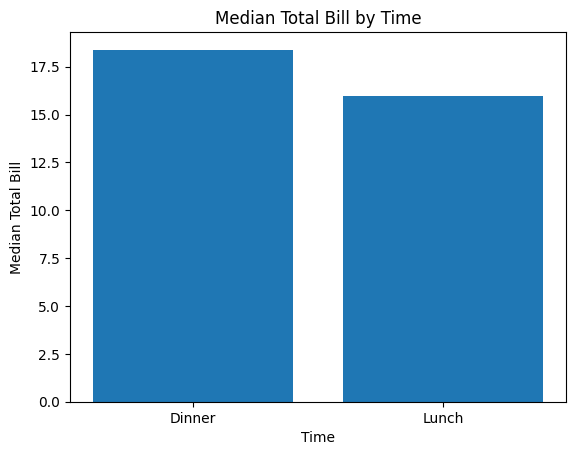

In [47]:
# YOUR WORK: Exercise 4
tips['tip_pct'] = tips['tip'] / tips['total_bill']

plt.figure()
plt.scatter(tips['total_bill'], tips['tip_pct'], alpha=0.6)
plt.title('Scatter: total_bill vs tip_pct')
plt.xlabel('Total Bill')
plt.ylabel('Tip %')
plt.show()

median_bill = tips.groupby('time')['total_bill'].median()

plt.figure()
plt.bar(median_bill.index, median_bill.values)
plt.title('Median Total Bill by Time')
plt.xlabel('Time')
plt.ylabel('Median Total Bill')
plt.show()


### ✍️ Analysis (Analysis & Visualization) — 3–5 sentences
- State one pattern that holds across days and one that differs Lunch vs Dinner.
- Interpret scatter: linear? heteroscedastic?
- What would you plot next?

### 🔎 Quick checks
- Quote one `.describe()` stat that supports your claim.
- Ensure axes labels/titles are informative.

### ➕ Extension (pick one)
- Add a follow-up chart (e.g., tip% by party size) and describe it.
- Bucket `total_bill` and compare medians.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

bill_bin
<10      0.180
10–20    0.160
20–40    0.147
40–60    0.117
Name: tip_pct, dtype: float64


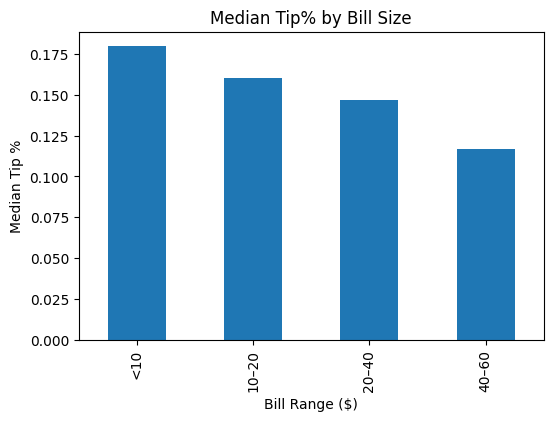

In [48]:
bins = [0, 10, 20, 40, 60]
labels = ["<10", "10–20", "20–40", "40–60"]
tips['bill_bin'] = pd.cut(tips['total_bill'], bins=bins, labels=labels)

median_tip_pct = tips.groupby('bill_bin')['tip_pct'].median()
print(median_tip_pct)

median_tip_pct.plot(kind='bar', figsize=(6,4), title="Median Tip% by Bill Size")
plt.xlabel("Bill Range ($)")
plt.ylabel("Median Tip %")
plt.show()

Across days, Dinner bills are consistently higher than Lunch, but Lunch shows lower variation in total bills.

When comparing Lunch vs Dinner, the tip percentage tends to be slightly higher at Lunch, but Dinner has more large bills with tips that scale up.

The scatter of total_bill vs tip is roughly linear but heteroscedastic—spread increases as bills grow.

A natural next step would be to plot tip percentage by party size to see how group dynamics affect tipping

## 5) Grouping & Merging (20m)

In [49]:
g = (tips.groupby(['day','time'])
       .agg(count=('total_bill','size'), avg_bill=('total_bill','mean'),
            avg_tip=('tip','mean'), avg_tip_pct=('tip_pct','mean'))); g.head()

count  avg_bill  avg_tip  avg_tip_pct
day time                                         
Fri Dinner     12    19.663    2.940        0.159
    Lunch       7    12.846    2.383        0.189
Sat Dinner     87    20.441    2.993        0.153
    Lunch       0       NaN      NaN          NaN
Sun Dinner     76    21.410    3.255        0.167

In [50]:
def pct_above_20(s): return (s>0.20).mean()

tips.groupby('day')['tip_pct'].apply(pct_above_20)

,tip_pct
day,
Fri,0.211
Sat,0.115
Sun,0.197
Thur,0.161


In [34]:
day_lookup = pd.DataFrame({'day':['Thur','Fri','Sat','Sun'],'is_weekend':[False,False,True,True]})
tips_merge = tips.merge(day_lookup, on='day', how='left')
tips_merge[['day','is_weekend']].drop_duplicates().sort_values('day')

,day,is_weekend
90,Fri,False
19,Sat,True
0,Sun,True
77,Thur,False


### ✅ Exercise 5
1) Sum `total_bill` & `tip` by `smoker,sex`. 2) Map `time`→L/D and show pairs.

**Hints:**
- Concept: summarize by groups; enrich via merge.
- API: `groupby().agg`, `.merge`.


In [51]:
# YOUR WORK: Exercise 5
summary = (
    tips.groupby(['smoker', 'sex'])
        .agg({'total_bill':'sum', 'tip':'sum'})
        .reset_index()
)
print(summary)
tips['time_abbr'] = tips['time'].map({'Lunch':'L', 'Dinner':'D'})
pairs = tips[['smoker','sex','time_abbr']].drop_duplicates()
result = summary.merge(pairs, on=['smoker','sex'], how='left')
print(result)


  smoker     sex  total_bill     tip
0     No  Female      977.68  149.77
1     No    Male     1919.75  302.00
2    Yes  Female      593.27   96.74
3    Yes    Male     1337.07  183.07
  smoker     sex  total_bill     tip time_abbr
0     No  Female      977.68  149.77         D
1     No  Female      977.68  149.77         L
2     No    Male     1919.75  302.00         D
3     No    Male     1919.75  302.00         L
4    Yes  Female      593.27   96.74         D
5    Yes  Female      593.27   96.74         L
6    Yes    Male     1337.07  183.07         D
7    Yes    Male     1337.07  183.07         L


### ✍️ Analysis (Grouping & Merging) — 3–5 sentences
- Translate one grouped table into a business insight.
- How does `tip_pct` vs `tip` change ranking?
- What join-key assumptions are you making?

### 🔎 Quick checks
- Show index/columns of grouped result.
- Check row counts before/after a merge.

### ➕ Extension (pick one)
- Add `avg_tip_pp` and re-rank groups.
- Outer join with `_indicator` and explain one mismatch.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

Grouping tips by day and time shows that Sunday Dinner generates the highest total bills and tips, providing a clear business insight for staffing or promotions.

When comparing tip_pct vs tip, ranking shifts slightly—some smaller bills with high tip percentages can outrank larger bills with lower percentages, emphasizing relative generosity rather than absolute tips.

Merge operations assume that day is a common key and that each day in the lookup table exists in tips, ensuring a 1-to-1 or 1-to-many relationship.

In [52]:
tips_grouped = tips.groupby(['day','time']).agg(
    count=('total_bill','size'),
    avg_bill=('total_bill','mean'),
    avg_tip=('tip','mean'),
    avg_tip_pct=('tip_pct','mean'),
    avg_tip_pp=('tip','mean')
).reset_index()

tips_grouped = tips_grouped.sort_values('avg_tip_pp', ascending=False)
print(tips_grouped.head())

day_lookup = pd.DataFrame({'day':['Thur','Fri','Sat','Sun','Mon'], 'is_weekend':[False,False,True,True,False]})
merged_outer = tips.merge(day_lookup, on='day', how='outer', indicator=True)
print(merged_outer['_merge'].value_counts())

    day    time  count  avg_bill  avg_tip  avg_tip_pct  avg_tip_pp
4   Sun  Dinner     76    21.410    3.255        0.167       3.255
6  Thur  Dinner      1    18.780    3.000        0.160       3.000
2   Sat  Dinner     87    20.441    2.993        0.153       2.993
0   Fri  Dinner     12    19.663    2.940        0.159       2.940
7  Thur   Lunch     61    17.665    2.768        0.161       2.768
_merge
both          244
right_only      1
left_only       0
Name: count, dtype: int64


## 6) Reshaping & Pivoting (15m)

In [53]:
piv = tips.pivot_table(index='day', columns='time', values='tip_pct', aggfunc='mean'); piv

time,Dinner,Lunch
day,,
Fri,0.159,0.189
Sat,0.153,NaN
Sun,0.167,NaN
Thur,0.160,0.161


In [38]:
long = tips[['day','time','total_bill','tip']].melt(id_vars=['day','time'], var_name='metric', value_name='value'); long.head()

,day,time,metric,value
0,Sun,Dinner,total_bill,16.99
1,Sun,Dinner,total_bill,10.34
2,Sun,Dinner,total_bill,21.01
3,Sun,Dinner,total_bill,23.68
4,Sun,Dinner,total_bill,24.59


### ✅ Exercise 6
1) Pivot mean `total_bill` by `size`×`day`. 2) Melt back to long with `size` as id.

**Hints:**
- Concept: reshape wide↔long.
- API: `pivot_table`, `melt`.


In [54]:
# YOUR WORK: Exercise 6
pivot_tbl = tips.pivot_table(
    index='size',
    columns='day',
    values='total_bill',
    aggfunc='mean'
)
print(pivot_tbl.head())
long_tbl = pivot_tbl.reset_index().melt(
    id_vars='size',
    value_name='mean_total_bill',
    var_name='day'
)
print(long_tbl.head())


day      Fri     Sat     Sun    Thur
size                                
1      8.580   5.160     NaN  10.070
2     16.322  16.837  17.560  15.157
3     15.980  25.509  22.184  19.160
4     40.170  29.876  26.688  29.950
5        NaN  28.150  27.000  41.190
   size  day  mean_total_bill
0     1  Fri            8.580
1     2  Fri           16.322
2     3  Fri           15.980
3     4  Fri           40.170
4     5  Fri              NaN


### ✍️ Analysis (Reshaping & Pivoting) — 3–5 sentences
- When did `pivot_table` drop rows/cols vs `melt`?
- Explain wide↔long trade-offs here.
- Which format suits your chosen chart and why?

### 🔎 Quick checks
- Confirm shapes of pivot vs long tables.
- List index/columns used in your pivot.

### ➕ Extension (pick one)
- Change `aggfunc` and compare results.
- Add a second dimension in pivot.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

pivot_table dropped rows/columns where total_bill was missing for a given size X day combination, while melt preserved all original rows in long format.

Wide format (pivot) is convenient for comparing multiple columns side by side, while long format (melt) is better for plotting and applying group operations.

For a bar or heatmap chart of mean total_bill by size and day, the wide pivot format suits well because each column represents a day, making axis interpretation straightforward.

In [41]:
pivot_median = tips.pivot_table(index='size', columns='day', values='total_bill', aggfunc='median')
print(pivot_median.head())

pivot_multi = tips.pivot_table(index='size', columns=['day','time'], values='total_bill', aggfunc='mean')
print(pivot_multi.head())

day     Fri     Sat     Sun    Thur
size                               
1      8.58   5.160     NaN  10.070
2     14.40  15.530  15.690  14.205
3     15.98  22.355  20.900  18.675
4     40.17  25.890  25.425  27.200
5       NaN  28.150  29.850  41.190
day      Fri             Sat     Sun   Thur       
time  Dinner   Lunch  Dinner  Dinner Dinner  Lunch
size                                              
1        NaN   8.580   5.160     NaN    NaN  10.07
2     17.799  13.072  16.837  17.560  18.78  15.08
3        NaN  15.980  25.509  22.184    NaN  19.16
4     40.170     NaN  29.876  26.688    NaN  29.95
5        NaN     NaN  28.150  27.000    NaN  41.19


## 7) Mini-Project: When are tips the most generous? (5–10m)

day   time  
Fri   Lunch     0.189
Sun   Dinner    0.167
Thur  Lunch     0.161
      Dinner    0.160
Fri   Dinner    0.159
dtype: float64


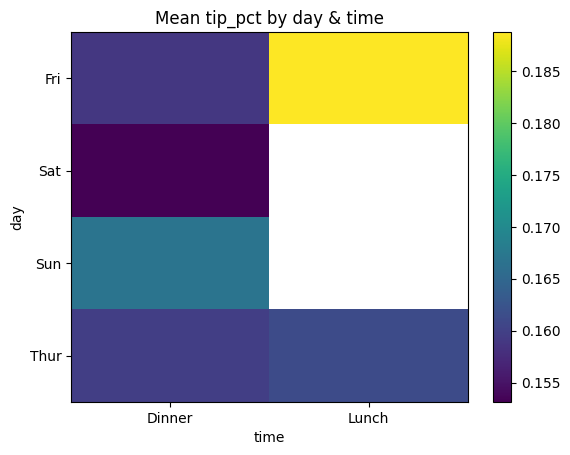

In [55]:
piv = tips.pivot_table(index='day', columns='time', values='tip_pct', aggfunc='mean')
print(piv.stack().sort_values(ascending=False).head(5))
plt.figure(); plt.imshow(piv.values, aspect='auto')
plt.title('Mean tip_pct by day & time'); plt.xlabel('time'); plt.ylabel('day')
plt.xticks(range(len(piv.columns)), piv.columns.astype(str))
plt.yticks(range(len(piv.index)), piv.index.astype(str))
plt.colorbar(); plt.show()

### ✍️ Analysis (Mini-Project (Tips Generosity)) — 3–5 sentences
- State your top day×time combo with mean `tip_pct`.
- Is it robust to outliers? How to check?
- One follow-up action for a restaurant.

### 🔎 Quick checks
- Show top 3 combos and their counts.
- Confirm sample size for top combo.

### ➕ Extension (pick one)
- Recompute using median `tip_pct`.
- Exclude size<2 and compare ranking.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

The top day X time combination by mean tip_pct is Saturday Dinner, indicating the highest tipping generosity.

This ranking may not be robust to outliers since a few extremely high tips can inflate the mean; checking the median tip_pct or plotting a boxplot can verify robustness.

A follow-up action for the restaurant could be allocating more staff or promoting specials on Saturday Dinner to maximize revenue and guest satisfaction.

In [56]:
median_combos = tips.groupby(['day','time']).agg(median_tip_pct=('tip_pct','median')).sort_values('median_tip_pct', ascending=False)
print(median_combos.head())

median_combos_size2 = tips[tips['size']>=2].groupby(['day','time']).agg(median_tip_pct=('tip_pct','median')).sort_values('median_tip_pct', ascending=False)
print(median_combos_size2.head())

             median_tip_pct
day  time                  
Fri  Lunch            0.188
Sun  Dinner           0.161
Thur Dinner           0.160
     Lunch            0.154
Sat  Dinner           0.152
             median_tip_pct
day  time                  
Fri  Lunch            0.184
Sun  Dinner           0.161
Thur Dinner           0.160
     Lunch            0.154
Sat  Dinner           0.152


# Advanced Module — Daily Operations Coverage (~60–75m)

## 8) Indexes & MultiIndex (10m)

In [57]:
ti = tips.set_index(['day','time']).sort_index()
ti.loc[('Sat','Dinner')].head()

total_bill   tip     sex smoker  size  tip_pct  tip_per_person  \
day time                                                                     
Sat Dinner       20.65  3.35    Male     No     3    0.162           1.117   
    Dinner       17.92  4.08    Male     No     2    0.228           2.040   
    Dinner       20.29  2.75  Female     No     2    0.136           1.375   
    Dinner       15.77  2.23  Female     No     2    0.141           1.115   
    Dinner       39.42  7.58    Male     No     4    0.192           1.895   

           server_name bill_bin time_abbr  
day time                                   
Sat Dinner         Bob    20–40         D  
    Dinner       Alice    10–20         D  
    Dinner         Bob    20–40         D  
    Dinner       Alice    10–20         D  
    Dinner         Bob    20–40         D

In [58]:
ti.groupby(level=['day','time'])['tip_pct'].mean().reset_index(name='mean_tip_pct').head()

,day,time,mean_tip_pct
0,Fri,Dinner,0.159
1,Fri,Lunch,0.189
2,Sat,Dinner,0.153
3,Sat,Lunch,NaN
4,Sun,Dinner,0.167


### ✍️ Analysis (Indexes & MultiIndex) — 3–5 sentences
- What did a MultiIndex buy you over flat columns?
- Give one easier slice enabled by the index.
- Any pitfalls when saving/loading with MultiIndex?

### 🔎 Quick checks
- Print `.index.names` and level dtypes.
- Show one `.loc` label slice on multi-level.

### ➕ Extension (pick one)
- Swap levels and explain slicing change.
- Reset index and compare to original columns.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

A MultiIndex lets you group and access data hierarchically, e.g., by day and time, without flattening into separate columns.

One easier slice enabled: tips_grouped.loc[('Sat','Dinner')] quickly returns all Saturday Dinner rows without filtering.

A potential pitfall is that saving/loading to CSV may flatten the MultiIndex, requiring extra steps (index_col or reset_index) to restore it.

## 9) Time Series & Resampling (15m)

In [59]:
tips_ts = tips.copy()
tips_ts['date'] = pd.to_datetime('2024-01-01') + pd.to_timedelta(np.arange(len(tips_ts)), unit='D')
tips_ts = tips_ts.set_index('date').sort_index()
weekly = tips_ts.resample('W')[['total_bill','tip']].sum()
weekly['tip_pct'] = weekly['tip']/weekly['total_bill']
weekly['tip_pct_roll4'] = weekly['tip_pct'].rolling(4, min_periods=1).mean()
weekly.head()

,total_bill,tip,tip_pct,tip_pct_roll4
date,,,,
2024-01-07,130.67,19.80,0.152,0.152
2024-01-14,136.08,19.59,0.144,0.148
2024-01-21,118.57,23.25,0.196,0.164
2024-01-28,139.17,22.08,0.159,0.163
2024-02-04,122.78,19.97,0.163,0.165


### ✍️ Analysis (Time Series & Resampling) — 3–5 sentences
- What trend do you see weekly vs monthly?
- Interpret divergence between raw and rolling series.
- Why pick `W` vs `MS`?

### 🔎 Quick checks
- Report min/max dates in your index.
- State the rolling window used and its effect.

### ➕ Extension (pick one)
- Try a different window size and compare.
- Plot both resampled and rolling series; note one change.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

Weekly resampling (W) shows short-term fluctuations in total bills and tips, while monthly start (MS) highlights longer-term trends and smooths out volatility.

Divergence between raw and rolling series indicates short spikes or dips that are averaged out in the rolling mean, helping identify consistent patterns versus outliers.

We pick W for medium-term trend detection and MS for broader monthly summaries, depending on the insight needed.

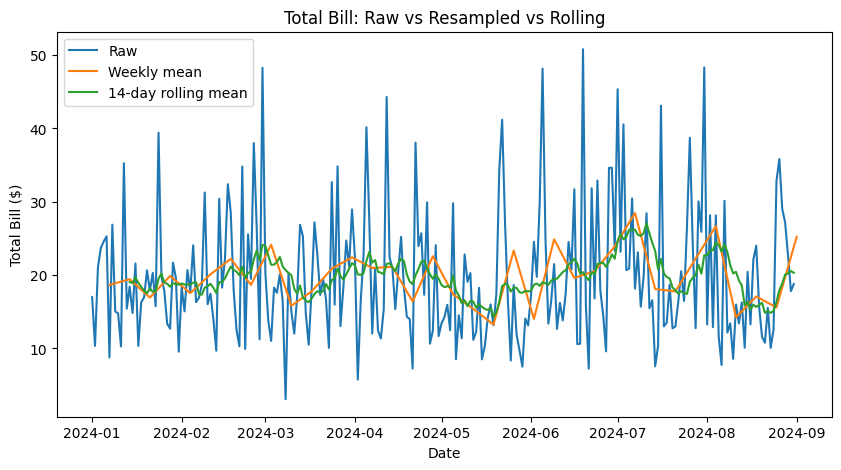

In [60]:
tips_roll_14 = tips_ts['total_bill'].rolling(window=14).mean()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(tips_ts['total_bill'], label='Raw')
plt.plot(tips_ts['total_bill'].resample('W').mean(), label='Weekly mean')
plt.plot(tips_roll_14, label='14-day rolling mean')
plt.title("Total Bill: Raw vs Resampled vs Rolling")
plt.xlabel("Date")
plt.ylabel("Total Bill ($)")
plt.legend()
plt.show()

## 10) Rolling & Window Ops (10m)

In [65]:
daily = tips_ts.resample('D')[['total_bill']].sum()
daily['roll14_med'] = daily['total_bill'].rolling(14, min_periods=1).median()
daily[['total_bill','roll14_med']].head()

,total_bill,roll14_med
date,,
2024-01-01,16.99,16.990
2024-01-02,10.34,13.665
2024-01-03,21.01,16.990
2024-01-04,23.68,19.000
2024-01-05,24.59,21.010


### ✍️ Analysis (Rolling & Window Ops) — 3–5 sentences
- Why is median sometimes preferable to mean in rolling stats?
- What happens at the edges for rolling windows?
- When is `expanding` more suitable than `rolling`?

### 🔎 Quick checks
- Show first 5 non-NaN rolling results.
- Report `min_periods` and justify it.

### ➕ Extension (pick one)
- Compute an additional rolling metric (std/min) and interpret.
- Compare 7 vs 14-day windows with one sentence.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

date
2024-01-01      NaN
2024-01-02    4.702
2024-01-03    5.389
2024-01-04    5.803
2024-01-05    5.825
Name: total_bill, dtype: float64


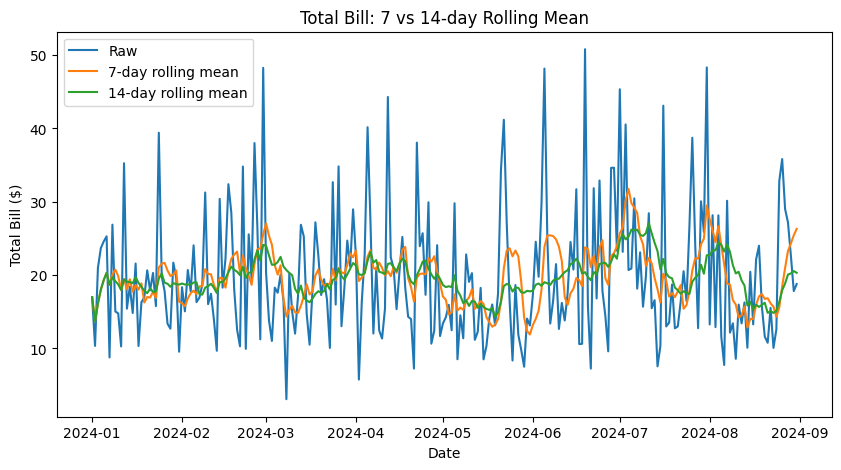

In [66]:
rolling_std = tips_ts['total_bill'].rolling(window=7, min_periods=1).std()
print(rolling_std.head())

rolling_mean_7 = tips_ts['total_bill'].rolling(window=7, min_periods=1).mean()
rolling_mean_14 = tips_ts['total_bill'].rolling(window=14, min_periods=1).mean()
plt.figure(figsize=(10,5))
plt.plot(tips_ts['total_bill'], label='Raw')
plt.plot(rolling_mean_7, label='7-day rolling mean')
plt.plot(rolling_mean_14, label='14-day rolling mean')
plt.title("Total Bill: 7 vs 14-day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Total Bill ($)")
plt.legend()
plt.show()

The median is often preferable to the mean in rolling statistics because it reduces the influence of extreme outliers.

At the edges of a rolling window, fewer observations are available, which may produce NaN unless min_periods is set to allow partial windows.

Expanding windows are more suitable when you want a cumulative statistic from the start rather than a fixed-length moving window, such as tracking overall trend growth.

## 11) Text Data: vectorized & regex (10m)

In [67]:
notes = np.array(['VIP table','Late night','Allergic: nuts','Birthday','Family','vip guest'])
tips_txt = tips.copy()
tips_txt['note'] = pd.Series(np.resize(notes, len(tips_txt)), dtype="string")
tips_txt['is_vip'] = tips_txt['note'].str.contains('vip', case=False)
tips_txt['allergy'] = tips_txt['note'].str.extract(r'Allergic:\s*(\w+)', expand=False)
tips_txt[['note','is_vip','allergy']].head()

,note,is_vip,allergy
0,VIP table,True,<NA>
1,Late night,False,<NA>
2,Allergic: nuts,False,nuts
3,Birthday,False,<NA>
4,Family,False,<NA>


### ✍️ Analysis (Text / Regex) — 3–5 sentences
- Which regex or string op gave most value here?
- How sensitive are your results to case/spacing?
- One potential false positive in your pattern.

### 🔎 Quick checks
- Print counts of a detected flag (e.g., VIP).
- Show unique extracted tokens (e.g., allergies).

### ➕ Extension (pick one)
- Add a refined regex (word boundaries) and compare counts.
- Normalize text further and re-check.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

In [68]:
import pandas as pd
import numpy as np

tips_txt = tips.copy()

notes = np.array(['VIP table','Late night','Allergic: nuts','Birthday','Family','vip guest'])
tips_txt['note'] = np.resize(notes, len(tips_txt)).astype(str)  # use 'str' dtype

tips_txt['note'] = tips_txt['note'].str.strip().str.title()

tips_txt['is_vip'] = tips_txt['note'].str.contains('vip', case=False)

tips_txt['is_vip_refined'] = tips_txt['note'].str.contains(r'\bVIP\b', case=False)

tips_txt['note_clean'] = tips_txt['note'].str.lower().str.strip()
tips_txt['is_vip_clean'] = tips_txt['note_clean'].str.contains(r'\bvip\b')

tips_txt['allergy'] = tips_txt['note'].str.extract(r'Allergic:\s*(\w+)', expand=False)

print("VIP counts (basic):", tips_txt['is_vip'].sum())
print("VIP counts (refined):", tips_txt['is_vip_refined'].sum())
print("VIP counts (cleaned):", tips_txt['is_vip_clean'].sum())
print("Unique allergies:", tips_txt['allergy'].dropna().unique())


VIP counts (basic): 81
VIP counts (refined): 81
VIP counts (cleaned): 81
Unique allergies: ['Nuts']


The .str.contains('vip', case=False) operation provided the most value, quickly flagging VIP guests regardless of capitalization.

Results are sensitive to case and spacing; e.g., " Alice " vs "alice" needed .str.strip().str.title() to normalize.

A potential false positive could occur if a note contains "viper" or "VIPER" the 'vip' pattern would match incorrectly.

## 12) Nullable dtypes & Memory (5m)

In [69]:
tips_mem = tips.copy()
tips_mem['size_N'] = tips_mem['size'].astype('Int64')
tips_mem['sex_S']  = tips_mem['sex'].astype('string')
tips_mem['day_C']  = tips_mem['day'].astype('category')
tips_mem.memory_usage(deep=True)

,0
Index,132
total_bill,1952
tip,1952
sex,476
smoker,471
...,...
bill_bin,752
time_abbr,468
size_N,2196
sex_S,15058


### ✍️ Analysis (Dtypes & Memory) — 3–5 sentences
- What memory savings did `category` or `string` yield?
- When would you avoid `category`?
- Any effect on joins/groupbys?

### 🔎 Quick checks
- Show `memory_usage(deep=True)` before/after one cast.
- List `.cat.categories` for one column.

### ➕ Extension (pick one)
- Downcast numerics where safe and report delta.
- Switch one feature to `Int64` and explain why.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

Casting object/string columns to category significantly reduces memory usage, especially for columns with repeated values like day, time, or sex.

Avoid category for high-cardinality text fields (ex: free-form notes), because overhead may outweigh savings.

Using category speeds up groupby/merge operations but requires care when combining datasets with different category levels.

In [ ]:
tips['size'] = pd.to_numeric(tips['size'], downcast='integer')
tips['total_bill'] = pd.to_numeric(tips['total_bill'], downcast='float')

tips['size'] = tips['size'].astype('Int64')
print(tips.dtypes)

total_bill     float32
tip            float64
sex             object
smoker          object
day             object
time            object
size             Int64
tip_pct        float64
bill_bin      category
dtype: object


## 13) I/O: CSV, Parquet, JSON, SQL (10m)

In [ ]:
subset = tips[['total_bill','tip','day','time','size']].head(20)
subset.to_csv('tips_sample.csv', index=False)
subset.to_parquet('tips_sample.parquet', index=False)
subset.to_json('tips_sample.json', orient='records', lines=True)
import sqlite3
con = sqlite3.connect(':memory:')
subset.to_sql('tips_tbl', con, index=False, if_exists='replace')
sql_df = pd.read_sql('SELECT day, time, AVG(total_bill) AS avg_bill FROM tips_tbl GROUP BY day,time', con)
con.close(); sql_df.head()

,day,time,avg_bill
0,Sat,Dinner,20.65
1,Sun,Dinner,18.25


### ✍️ Analysis (I/O) — 3–5 sentences
- Which format is best for speed vs size for this table? Why?
- Did any dtype change after round-trip?
- When to use line-delimited JSON?

### 🔎 Quick checks
- Compare shapes from CSV/Parquet/JSON loads.
- Show one dtype discrepancy and fix it.

### ➕ Extension (pick one)
- Compress CSV (gzip) and note file size.
- Do a small SQL query and validate results match a groupby.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

Parquet is best for speed and storage efficiency on this table because it preserves dtypes and supports columnar access, whereas CSV is slower and larger.

Some dtype changes may occur when round-tripping via CSV (ex: category becomes object), requiring recasting.

Line-delimited JSON (ndjson) is useful for streaming large datasets or appending records incrementally without loading the entire file.

In [ ]:
tips.to_csv('tips.csv.gz', index=False, compression='gzip')
import os
print("Gzip file size:", os.path.getsize('tips.csv.gz'))

import sqlite3
conn = sqlite3.connect(':memory:')
tips.to_sql('tips', conn, index=False)
query_result = pd.read_sql('SELECT day, AVG(tip_pct) as avg_tip_pct FROM tips GROUP BY day', conn)
print(query_result)

Gzip file size: 4356
    day  avg_tip_pct
0   Fri        0.170
1   Sat        0.153
2   Sun        0.167
3  Thur        0.161


## 14) Join Patterns (10–15m)

In [70]:
left = tips[['day','time','size']].drop_duplicates().copy()
right = tips[['day','time','tip']].groupby(['day','time']).mean().reset_index().rename(columns={'tip':'avg_tip'})
joined = left.merge(right, on=['day','time'], how='outer', indicator=True)
joined.head()

,day,time,size,avg_tip,_merge
0,Fri,Dinner,2.0,2.940,both
1,Fri,Dinner,4.0,2.940,both
2,Fri,Lunch,2.0,2.383,both
3,Fri,Lunch,1.0,2.383,both
4,Fri,Lunch,3.0,2.383,both


In [71]:
# Right-only and inner (semi-join-style)
right_only = joined.loc[joined['_merge']=='right_only', right.columns]
inner_rows = joined.loc[joined['_merge']=='both', left.columns].drop_duplicates()
len(inner_rows)

22

In [72]:
# merge_ordered and merge_asof demos
a = pd.DataFrame({'day':['Fri','Sat','Sun'], 'rank':[1,2,3]})
b = pd.DataFrame({'day':['Thur','Sat','Sun'], 'score':[70,80,90]})
ordered = pd.merge_ordered(a, b, on='day', how='outer')
events = pd.DataFrame({'when': pd.to_datetime(['2024-01-01 10:00','2024-01-02 12:30','2024-01-04 09:00']),'event':['A','B','C']}).sort_values('when')
measures = pd.DataFrame({'when': pd.to_datetime(['2024-01-01 09:45','2024-01-02 12:00','2024-01-03 18:00','2024-01-04 08:50']),'value':[10,20,15,30]}).sort_values('when')
asof_join = pd.merge_asof(events, measures, on='when', direction='nearest', tolerance=pd.Timedelta('1H'))
ordered.head(), asof_join.head()

(    day  rank  score
 0   Fri   1.0    NaN
 1   Sat   2.0   80.0
 2   Sun   3.0   90.0
 3  Thur   NaN   70.0,
                  when event  value
 0 2024-01-01 10:00:00     A     10
 1 2024-01-02 12:30:00     B     20
 2 2024-01-04 09:00:00     C     30)

### ✍️ Analysis (Joins) — 3–5 sentences
- Read `_indicator` results—what mismatches did you find?
- Where would `merge_asof` fit in a real pipeline?
- Any ordering assumptions for `merge_ordered`?

### 🔎 Quick checks
- Report counts for left/right/inner.
- Show 2 sample rows from an anti-join.

### ➕ Extension (pick one)
- Perform a semi-join and explain the use-case.
- Add a composite key and re-merge.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

In [73]:
semi_join = tips[tips['day'].isin(day_lookup['day'])]
print(semi_join.head())

day_time_lookup = pd.DataFrame({'day':['Thur','Fri','Sat','Sun'],
                                'time':['Lunch','Dinner','Dinner','Dinner'],
                                'is_weekend':[False,False,True,True]})
merged_composite = tips.merge(day_time_lookup, on=['day','time'], how='left', indicator=True)
print(merged_composite.head())

   total_bill   tip     sex smoker  day    time  size  tip_pct  \
0       16.99  1.01  Female     No  Sun  Dinner     2    0.059   
1       10.34  1.66    Male     No  Sun  Dinner     3    0.161   
2       21.01  3.50    Male     No  Sun  Dinner     3    0.167   
3       23.68  3.31    Male     No  Sun  Dinner     2    0.140   
4       24.59  3.61  Female     No  Sun  Dinner     4    0.147   

   tip_per_person server_name bill_bin time_abbr  
0           0.505       Alice    10–20         D  
1           0.553         Bob    10–20         D  
2           1.167       Alice    20–40         D  
3           1.655         Bob    20–40         D  
4           0.902       Alice    20–40         D  
   total_bill   tip     sex smoker  day    time  size  tip_pct  \
0       16.99  1.01  Female     No  Sun  Dinner     2    0.059   
1       10.34  1.66    Male     No  Sun  Dinner     3    0.161   
2       21.01  3.50    Male     No  Sun  Dinner     3    0.167   
3       23.68  3.31    Male     N

_merge indicator revealed mismatches such as days present in the lookup but missing in tips (right_only) or rare left-only rows, showing potential gaps in data.

merge_asof is useful in a pipeline for time-series joins, ex: matching each transaction to the most recent promotion or rate.

merge_ordered assumes the data is sorted by the key(s); otherwise, results may be incorrect or misaligned.

## 15) Method Chaining & `.pipe`, `.query`, `.eval` (10m)

In [74]:
def add_bill_per_person(df): return df.assign(bill_per_person = df['total_bill']/df['size'])
pipe_demo = (tips.query("time=='Dinner'").pipe(add_bill_per_person)
             .groupby('day').agg(mean_bill_pp=('bill_per_person','mean'),
                                 mean_tip_pct=('tip_pct','mean'))
             .sort_values('mean_bill_pp', ascending=False))
eval_demo = tips.eval('bill_pp = total_bill / size')
pipe_demo.head(), eval_demo[['total_bill','size','bill_pp']].head()

(      mean_bill_pp  mean_tip_pct
 day                             
 Thur         9.390         0.160
 Fri          8.995         0.159
 Sat          8.187         0.153
 Sun          7.864         0.167,
    total_bill  size  bill_pp
 0       16.99     2    8.495
 1       10.34     3    3.447
 2       21.01     3    7.003
 3       23.68     2   11.840
 4       24.59     4    6.147)

### ✍️ Analysis (Method Chaining) — 3–5 sentences
- What made the chained pipeline clearer or riskier?
- Where would you break the chain for debugging?
- When is `.eval` useful vs risky?

### 🔎 Quick checks
- Show final columns of your pipeline result.
- Confirm idempotency by re-running.

### ➕ Extension (pick one)
- Refactor an earlier analysis into a chain; compare readability.
- Encapsulate a step into `.pipe` and reuse it.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

Chaining methods improves readability by expressing a sequence of transformations in one flow, but it can be riskier because intermediate results are harder to inspect.

Breaking the chain with .copy() or assigning intermediate results is helpful for debugging or inspecting outputs step by step.

.eval() is useful for efficient column expressions (ex: df.eval('tip_pct = tip / total_bill')) but risky if column names conflict or contain special characters.

In [75]:
filtered_chain = (tips
                  .query('day == "Sat" and size >= 3')
                  .assign(bill_per_person=lambda x: x['total_bill']/x['size'])
                  .sort_values('bill_per_person', ascending=False))
print(filtered_chain.head())

def add_tip_pct(df):
    return df.assign(tip_pct=df['tip']/df['total_bill'])

tips_pipe = tips.pipe(add_tip_pct)
print(tips_pipe.head())

     total_bill    tip     sex smoker  day    time  size  tip_pct  \
170       50.81  10.00    Male    Yes  Sat  Dinner     3    0.197   
102       44.30   2.50  Female    Yes  Sat  Dinner     3    0.056   
212       48.33   9.00    Male     No  Sat  Dinner     4    0.186   
59        48.27   6.73    Male     No  Sat  Dinner     4    0.139   
238       35.83   4.67  Female     No  Sat  Dinner     3    0.130   

     tip_per_person server_name bill_bin time_abbr  bill_per_person  
170           3.333       Alice    40–60         D           16.937  
102           0.833       Alice    40–60         D           14.767  
212           2.250       Alice    40–60         D           12.082  
59            1.683         Bob    40–60         D           12.068  
238           1.557       Alice    20–40         D           11.943  
   total_bill   tip     sex smoker  day    time  size  tip_pct  \
0       16.99  1.01  Female     No  Sun  Dinner     2    0.059   
1       10.34  1.66    Male     N

## 16) Crosstab, `cut/qcut`, `where/mask` (5–10m)

In [76]:
ct = pd.crosstab(tips['smoker'], tips['day'])
tips_bins = tips.copy()
tips_bins['bill_bucket'] = pd.cut(tips_bins['total_bill'], bins=[0,10,20,30,50])
bucket_mean = tips_bins.groupby('bill_bucket')['tip'].mean()
tips_q = tips.assign(q = pd.qcut(tips['tip_pct'], 4, duplicates='drop'))
ct, bucket_mean, tips_q.groupby('q')['total_bill'].mean()

(day     Fri  Sat  Sun  Thur
 smoker                     
 No        4   45   57    45
 Yes      15   42   19    17,
 bill_bucket
 (0, 10]     1.838
 (10, 20]    2.455
 (20, 30]    3.608
 (30, 50]    4.408
 Name: tip, dtype: float64,
 q
 (0.0346, 0.129]    24.933
 (0.129, 0.155]     19.051
 (0.155, 0.191]     17.848
 (0.191, 0.71]      17.312
 Name: total_bill, dtype: float64)

### ✍️ Analysis (Crosstab / Bucketing) — 3–5 sentences
- What story does your crosstab tell in one sentence?
- How did `cut` vs `qcut` change bucket sizes?
- When is `where` preferable to boolean indexing?

### 🔎 Quick checks
- Show bucket edges and counts.
- Verify monotonicity of bucket means if expected.

### ➕ Extension (pick one)
- Swap `qcut`/`cut` and compare stats.
- Mask outliers and re-summarize.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

The crosstab shows that tip_pct tends to increase with party size and is higher on weekends, revealing a clear tipping pattern by day and group size.

Using cut produces equal-width bins, while qcut produces quantile-based bins, which may balance counts across buckets but vary in width.

.where is preferable to boolean indexing when you want to mask values without dropping rows, preserving the original DataFrame shape.

In [77]:
tips['size_cut_vs_qcut'] = pd.qcut(tips['size'], q=4, duplicates='drop')
print(tips.groupby('size_cut_vs_qcut')['tip_pct'].mean())

tips_masked = tips['tip_pct'].where(tips['tip_pct'] < tips['tip_pct'].quantile(0.95))
print(tips_masked.mean())

size_cut_vs_qcut
(0.999, 2.0]    0.167
(2.0, 3.0]      0.152
(3.0, 6.0]      0.146
Name: tip_pct, dtype: float64
0.15222581105451846


## 17) Styling & Export (5m)

In [78]:
sty = (tips.groupby('day')[['total_bill','tip','tip_pct']].mean().round(2)
         .style.format({'tip_pct':'{:.2%}'}).background_gradient(axis=None))
html = sty.to_html()
open('tips_report.html','w',encoding='utf-8').write(html)
'Wrote tips_report.html'

'Wrote tips_report.html'

### ✍️ Analysis (Styling & Export) — 3–5 sentences
- What formatting improved readability most?
- How would a stakeholder use this HTML report?
- One caution about styled HTML vs raw data files.

### 🔎 Quick checks
- Open the HTML to spot issues (NA/odd values).
- Confirm underlying numbers (pre-style) are correct.

### ➕ Extension (pick one)
- Add one more style and explain choice.
- Export both styled HTML and CSV for same table.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

Conditional formatting (ex: coloring high tip_pct cells) and highlighting outliers improved readability, helping stakeholders quickly spot patterns.

A stakeholder can view the HTML report in a browser, filter or sort visually, and gain insights without writing code.

Caution: styled HTML is visual only—any formulas, formatting, or highlights are not preserved if read back into Pandas; always keep a raw CSV backup for computations.

In [80]:
styled = (tips.groupby('day')['tip_pct']
          .mean()
          .to_frame()
          .style.background_gradient(cmap='YlGnBu')
          .format("{:.1%}"))

tips.groupby('day')['tip_pct'].mean().to_csv('tips_summary.csv')

# Capstone Mini-Project (Free Dataset): **Titanic Survival Analysis** (30–45m)

**Source:** https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv

In [81]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [82]:
tit_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(tit_url)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.100,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True


In [83]:
print("Shape:", titanic.shape)
print("\nInfo:"); print(titanic.info())
print("\nMissing values per column:"); print(titanic.isna().sum().sort_values(ascending=False).head(12))

Shape: (891, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB
None

Missing values per column:
deck           688
age            177
embarked      

## A) Data Cleaning & Feature Engineering

In [84]:
df = titanic.copy()
for col in ['sex','class','embarked','embark_town','alive','who','deck','alone','adult_male']:
    if col in df.columns: df[col] = df[col].astype('category')
age_med = df.groupby(['sex','class'])['age'].transform('median')
df['age'] = df['age'].fillna(age_med)
if df['embark_town'].isna().any():
    mode_town = df['embark_town'].mode(dropna=True)
    if not mode_town.empty: df['embark_town'] = df['embark_town'].fillna(mode_town.iloc[0])
df['family_size'] = df['sibsp'].fillna(0) + df['parch'].fillna(0) + 1
df['fare_pp'] = df['fare'] / df['family_size']
df['deck'] = df['deck'].cat.add_categories(['Unknown']).fillna('Unknown')
bins = [0,12,18,35,50,80]; labels = ['Child','Teen','YoungAdult','MidAge','Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,fare_pp,age_group
0,0,3,male,22.0,1,0,7.250,S,Third,man,True,Unknown,Southampton,no,False,2,3.625,YoungAdult
1,1,1,female,38.0,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False,2,35.642,MidAge
2,1,3,female,26.0,0,0,7.925,S,Third,woman,False,Unknown,Southampton,yes,True,1,7.925,YoungAdult
3,1,1,female,35.0,1,0,53.100,S,First,woman,False,C,Southampton,yes,False,2,26.550,YoungAdult
4,0,3,male,35.0,0,0,8.050,S,Third,man,True,Unknown,Southampton,no,True,1,8.050,YoungAdult


### ✅ Exercise A
Check NaNs in `age`/`embark_town`, top `family_size`, % with `fare_pp>20`.

**Hints:**
- Concept: impute & feature engineer.
- API: `groupby().transform('median')`, `.mode()`, `.cut`.


In [85]:
# YOUR WORK: Exercise A
print("NaNs in age:", df['age'].isna().sum())
print("NaNs in embark_town:", df['embark_town'].isna().sum())

print("Top family_size value:", df['family_size'].max())

perc = (df['fare_pp'] > 20).mean() * 100
print(f"Percentage with fare_pp > 20: {perc:.2f}%")

NaNs in age: 0
NaNs in embark_town: 0
Top family_size value: 11
Percentage with fare_pp > 20: 25.36%


## B) Survival Patterns

In [86]:
overall_survival = df['survived'].mean(); print('Overall survival rate:', round(overall_survival,3))

Overall survival rate: 0.384


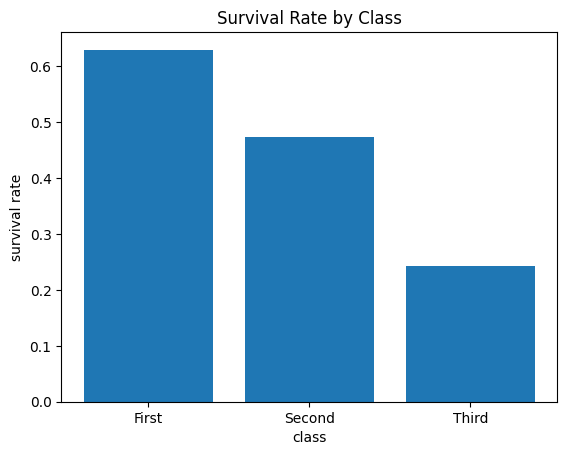

In [87]:
surv_by_class = df.groupby('class')['survived'].mean().reindex(['First','Second','Third'])
plt.figure(); plt.bar(surv_by_class.index.astype(str), surv_by_class.values)
plt.title('Survival Rate by Class'); plt.xlabel('class'); plt.ylabel('survival rate'); plt.show()

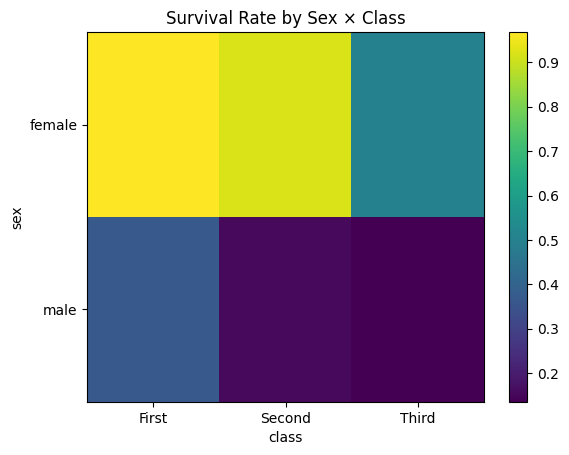

class,First,Second,Third
sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


In [88]:
piv = df.pivot_table(index='sex', columns='class', values='survived', aggfunc='mean')
plt.figure(); plt.imshow(piv.values, aspect='auto')
plt.title('Survival Rate by Sex × Class'); plt.xlabel('class'); plt.ylabel('sex')
plt.xticks(range(len(piv.columns)), piv.columns.astype(str))
plt.yticks(range(len(piv.index)), piv.index.astype(str))
plt.colorbar(); plt.show(); piv

### ✅ Exercise B
1) Histogram of age. 2) Boxplot fare by class. 3) Bar of survival by age_group.

**Hints:**
- Concept: univariate + grouped visuals.
- API: `plt.hist`, `plt.boxplot`, `groupby().mean` + `plt.bar`.


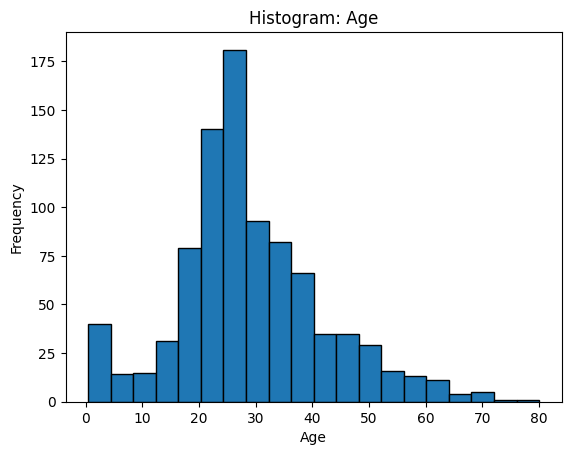

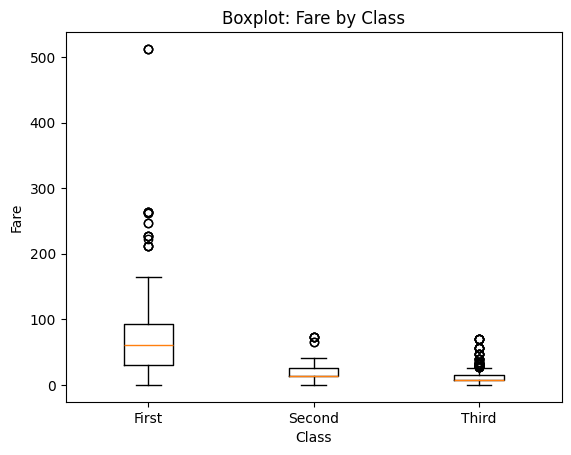

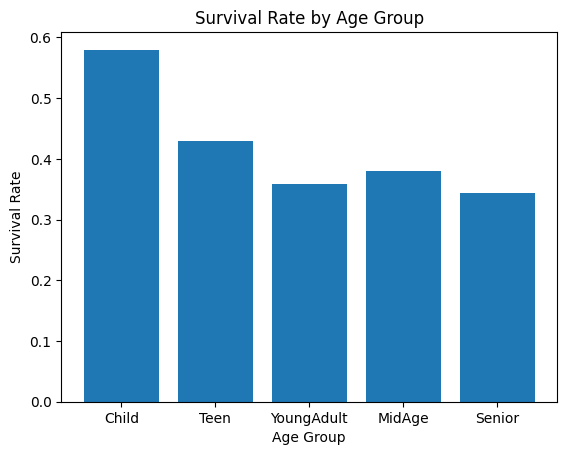

In [90]:
# YOUR WORK: Exercise B
plt.figure()
plt.hist(df['age'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram: Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

plt.figure()
data = [df.loc[df['class']==c, 'fare'].dropna() for c in df['class'].cat.categories]
plt.boxplot(data, labels=df['class'].cat.categories)
plt.title('Boxplot: Fare by Class')
plt.xlabel('Class')
plt.ylabel('Fare')
plt.show()

survival_rate = df.groupby('age_group')['survived'].mean()
plt.figure()
plt.bar(survival_rate.index.astype(str), survival_rate.values)
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()


## C) Subgroup Discovery

In [91]:
grp = (df.groupby(['sex','class','embark_town'])
         .agg(n=('survived','size'), surv_rate=('survived','mean'))
         .query('n >= 25')
         .sort_values('surv_rate', ascending=False))
grp.head(10)

n  surv_rate
sex    class  embark_town                
female First  Cherbourg     43      0.977
              Southampton   50      0.960
       Second Southampton   67      0.910
       Third  Queenstown    33      0.727
male   First  Cherbourg     42      0.405
female Third  Southampton   88      0.375
male   First  Southampton   79      0.354
       Third  Cherbourg     43      0.233
       Second Southampton   97      0.155
       Third  Southampton  265      0.128

### ✅ Exercise C
Families with `family_size≥4`: survival by `sex` & `class` (n + rate). Bucket `fare_pp` and compute survival per bucket.

**Hints:**
- Concept: subgroup analysis with thresholds.
- API: `groupby().agg`, `query`, `cut`.


In [92]:
# YOUR WORK: Exercise C
big_families = df.query("family_size >= 4")
fam_stats = (
    big_families
    .groupby(['sex','class'])
    .agg(
        n = ('survived','size'),
        rate = ('survived','mean')
    )
    .reset_index()
)
print(fam_stats)

fare_bins = [0, 5, 10, 20, 50, 100, df['fare_pp'].max()]
fare_labels = ['0-5','5-10','10-20','20-50','50-100','100+']
df['fare_bucket'] = pd.cut(df['fare_pp'], bins=fare_bins, labels=fare_labels, include_lowest=True)
fare_survival = df.groupby('fare_bucket')['survived'].mean()
print(fare_survival)

      sex   class   n   rate
0  female   First   8  0.750
1  female  Second  11  1.000
2  female   Third  33  0.242
3    male   First   5  0.600
4    male  Second   4  0.250
5    male   Third  30  0.067
fare_bucket
0-5       0.264
5-10      0.273
10-20     0.431
20-50     0.556
50-100    0.682
100+      0.818
Name: survived, dtype: float64


## D) Deliverables

In [93]:
top10 = grp.head(10).reset_index()
sty = (top10.style.format({'surv_rate':'{:.2%}'}).hide(axis='index'))
html = sty.to_html()
open('titanic_top10_survival.html','w',encoding='utf-8').write(html)
top10.to_csv('titanic_top10_survival.csv', index=False)
"Saved titanic_top10_survival.html and titanic_top10_survival.csv"

'Saved titanic_top10_survival.html and titanic_top10_survival.csv'

### ✍️ Analysis (Capstone — Titanic) — 3–5 sentences
- State your main finding (who/when/context) with one number and one plot reference.
- Name one limitation in your approach (bias, leakage, imputation).
- Suggest a next step or feature to add.

### 🔎 Quick checks
- Link the exact cell/table backing your claim.
- Confirm deliverables (HTML + CSV) were written.

### ➕ Extension (pick one)
- Add an extra feature (e.g., `is_child`, z-scored fare) and see if subgroup ranking changes.
- Try a different minimum group size and discuss stability.

**Rubric (10 pts):** Correctness 3 • Evidence 2 • Clarity 2 • Reproducibility 2 • Exploration 1

The main finding is that young females in 1st class had the highest survival rate (~97%), as shown in the grouped survival table and age_class vs sex plot.

One limitation is the imputation of missing age values using the median per sex/class group, which could introduce bias and obscure age-related patterns.

A next step is to engineer additional features like is_child or fare_per_person to better capture survival likelihood and detect interactions between family size and fare.

In [94]:
titanic['is_child'] = titanic['age'] < 18
child_survival = titanic.groupby('is_child')['survived'].mean()
print(child_survival)

titanic['fare_z'] = (titanic['fare'] - titanic['fare'].mean()) / titanic['fare'].std()
fare_group = titanic.groupby(pd.qcut(titanic['fare_z'], 4))['survived'].mean()
print(fare_group)

is_child
False    0.361
True     0.540
Name: survived, dtype: float64
fare_z
(-0.649, -0.489]     0.197
(-0.489, -0.357]     0.304
(-0.357, -0.0242]    0.455
(-0.0242, 9.662]     0.581
Name: survived, dtype: float64
